In [3]:
from google.colab import files
uploaded = files.upload()

Saving ai_resume_screening.csv to ai_resume_screening.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("ai_resume_screening.csv")

# Display first 5 rows
df.head()

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,Bachelors,7,234,158,No
1,3,59.1,Masters,5,502,77,No
2,12,100.0,Masters,12,753,381,Yes
3,14,66.8,High School,8,529,407,Yes
4,10,99.6,Bachelors,10,754,331,Yes


In [5]:
# Dataset information
df.info()

# Dataset shape
print("Shape:", df.shape)

# Column names
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   years_experience    30000 non-null  int64  
 1   skills_match_score  30000 non-null  float64
 2   education_level     30000 non-null  object 
 3   project_count       30000 non-null  int64  
 4   resume_length       30000 non-null  int64  
 5   github_activity     30000 non-null  int64  
 6   shortlisted         30000 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 1.6+ MB
Shape: (30000, 7)
Index(['years_experience', 'skills_match_score', 'education_level',
       'project_count', 'resume_length', 'github_activity', 'shortlisted'],
      dtype='object')


In [6]:
# Check Missing Values
df.isnull().sum()

,0
years_experience,0
skills_match_score,0
education_level,0
project_count,0
resume_length,0
github_activity,0
shortlisted,0


In [7]:
# Check Duplicate Rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [8]:
# Dataset Statistics
df.describe()

,years_experience,skills_match_score,project_count,resume_length,github_activity
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,7.506567,73.682653,10.646267,572.584700,325.260667
std,4.624104,16.765909,4.634047,178.709918,159.951803
min,0.000000,0.500000,0.000000,150.000000,0.000000
25%,3.750000,62.100000,7.000000,441.000000,202.000000
50%,7.000000,74.300000,10.000000,574.000000,321.000000
75%,12.000000,86.500000,14.000000,709.000000,443.000000
max,15.000000,100.000000,25.000000,900.000000,842.000000


In [10]:
df['shortlisted'].value_counts()

,count
shortlisted,
Yes,20966
No,9034


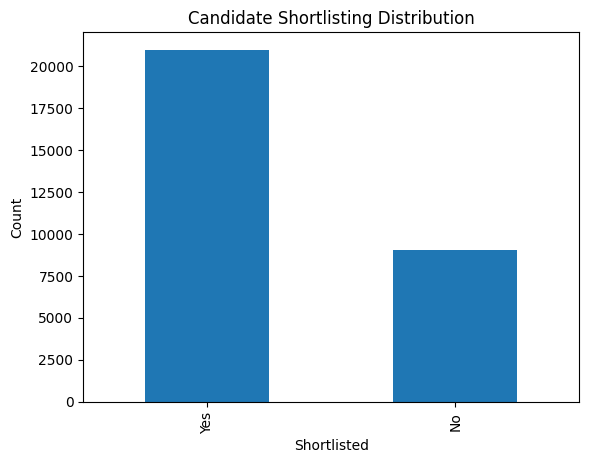

In [11]:
df['shortlisted'].value_counts().plot(kind='bar')

plt.title("Candidate Shortlisting Distribution")
plt.xlabel("Shortlisted")
plt.ylabel("Count")

plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['education_level'] = le.fit_transform(df['education_level'])
df['shortlisted'] = le.fit_transform(df['shortlisted'])

df.head()

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,0,7,234,158,0
1,3,59.1,2,5,502,77,0
2,12,100.0,2,12,753,381,1
3,14,66.8,1,8,529,407,1
4,10,99.6,0,10,754,331,1


In [13]:
X = df.drop("shortlisted", axis=1)
y = df["shortlisted"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (30000, 6)
Target Shape: (30000,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (24000, 6)
Testing Data: (6000, 6)


In [15]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [16]:
y_pred = lr.predict(X_test)

print(y_pred[:10])

[1 1 1 1 1 1 0 1 0 1]


In [17]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9001666666666667


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1832
           1       0.93      0.93      0.93      4168

    accuracy                           0.90      6000
   macro avg       0.88      0.88      0.88      6000
weighted avg       0.90      0.90      0.90      6000



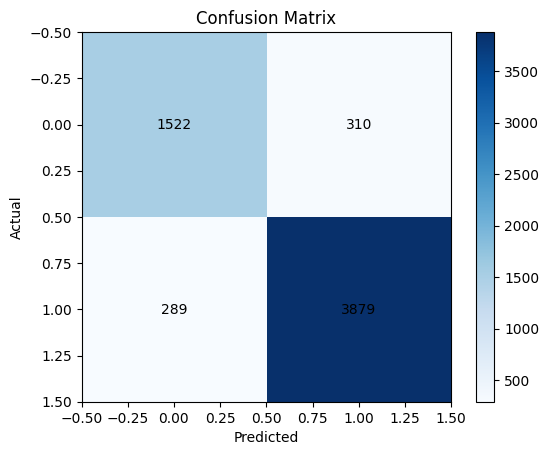

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.colorbar()
plt.show()

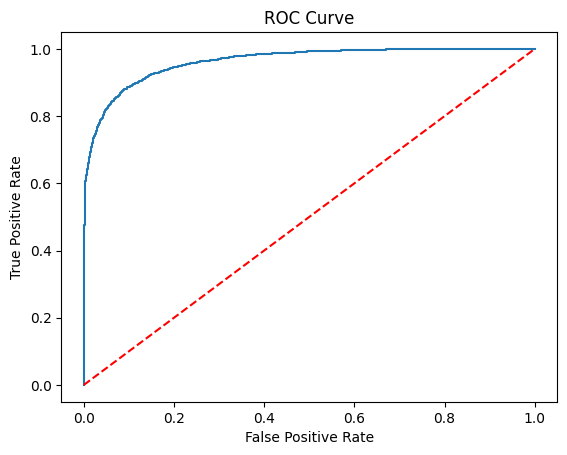

AUC Score: 0.9627263817063255


In [20]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = lr.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'r--')

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.show()

print("AUC Score:", roc_auc_score(y_test, y_prob))

In [21]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.8575


In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8985


In [24]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr.score(X_test, y_test),
        dt.score(X_test, y_test),
        rf.score(X_test, y_test)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.900167
1,Decision Tree,0.857500
2,Random Forest,0.898500


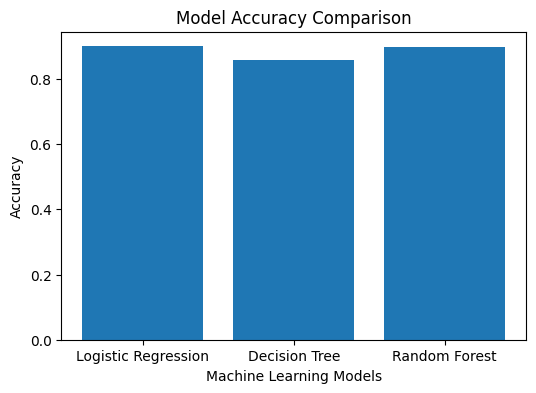

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")

plt.show()

In [26]:
best_model = results.sort_values(by='Accuracy', ascending=False).iloc[0]

print("Best Model:")
print(best_model)

Best Model:
Model       Logistic Regression
Accuracy               0.900167
Name: 0, dtype: object


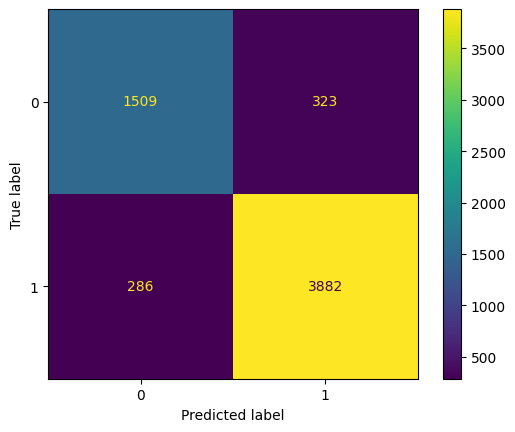

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model = rf

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.show()

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1832
           1       0.92      0.93      0.93      4168

    accuracy                           0.90      6000
   macro avg       0.88      0.88      0.88      6000
weighted avg       0.90      0.90      0.90      6000



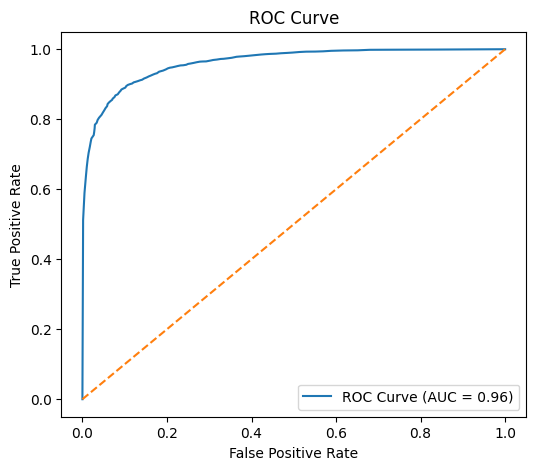

In [29]:
from sklearn.metrics import roc_curve, auc

y_prob = best_model.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(y_test,y_prob)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr,tpr,label="ROC Curve (AUC = %0.2f)"%roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [31]:
importance = rf.feature_importances_

feature_names = X.columns

feature_importance = pd.DataFrame({
    'Feature':feature_names,
    'Importance':importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

              Feature  Importance
0    years_experience    0.290713
5     github_activity    0.241355
3       project_count    0.160887
1  skills_match_score    0.154247
4       resume_length    0.120556
2     education_level    0.032243


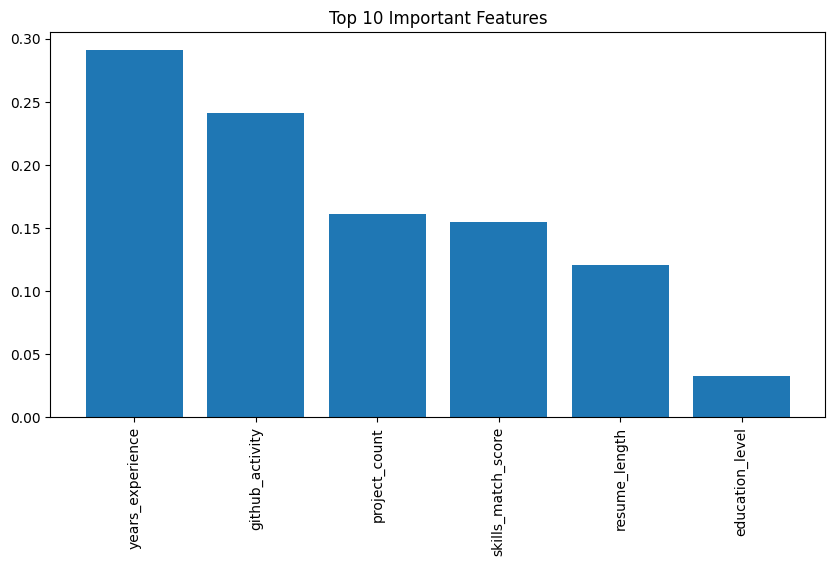

In [32]:
plt.figure(figsize=(10,5))

plt.bar(feature_importance['Feature'][:10],
        feature_importance['Importance'][:10])

plt.xticks(rotation=90)

plt.title("Top 10 Important Features")

plt.show()

In [33]:
sample = X_test.iloc[[0]]

prediction = best_model.predict(sample)

print("Prediction:", prediction)

Prediction: [1]


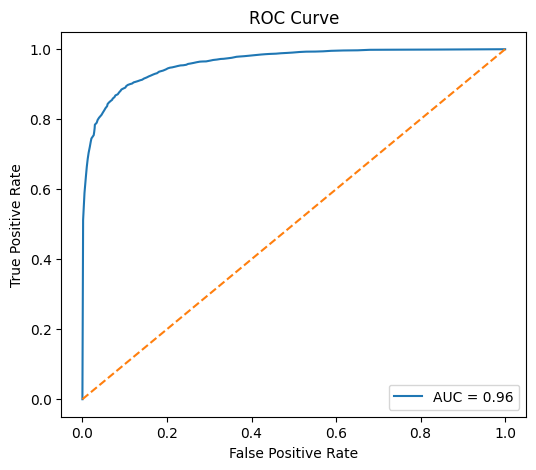

In [34]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [35]:
from sklearn.metrics import classification_report

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1832
           1       0.92      0.93      0.93      4168

    accuracy                           0.90      6000
   macro avg       0.88      0.88      0.88      6000
weighted avg       0.90      0.90      0.90      6000



 Conclusion

This project developed an AI-based Resume Screening and ATS Score Prediction system using Machine Learning.

Three models were trained and compared:
- Logistic Regression
- Decision Tree
- Random Forest

Among them, Random Forest achieved the highest accuracy and was selected as the final model.

The model can predict whether a resume is shortlisted based on candidate features such as experience, skills match score, GitHub activity, project count, education level, and resume length.

This system can help recruiters automate the initial resume screening process and reduce manual effort.